# Reconstrucción de Videos de Gestos desde Datos Esqueletales XML

Este notebook reconstruye videos de gestos de mano desde archivos XML, con soporte para cámara lenta, múltiples pacientes y verificación de secuencias.

**Flujo:**
1. Inspeccionar estructura del dataset
2. Parsear XML de datos esqueletales
3. Verificar si secuencias pertenecen al mismo video
4. Seleccionar secuencias representativas por gesto
5. Visualizar esqueletos en 2D
6. Generar videos a cámara lenta

## Sección 1: Importar librerías y configurar el entorno

In [6]:
# Importar librerías
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Configuración global
DATASET_BASE = Path("../data/dataset_skeletal_hand_gesture/skeletal")
OUTPUT_BASE = Path("../skeleton_videos")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# Parámetros de video
FPS_ORIGINAL = 30  # FPS estimado del dataset
FPS_SLOWMOTION = 10  # FPS para cámara lenta
CANVAS_SIZE = (800, 600)
FRAME_DUPLICATION = FPS_ORIGINAL // FPS_SLOWMOTION  # Duplicar cada frame N veces

# Colores para dedos en BGR
FINGER_COLORS = {
    'Thumb': (0, 0, 255),      # Rojo
    'Index': (0, 255, 0),      # Verde
    'Middle': (255, 0, 0),     # Azul
    'Ring': (0, 255, 255),     # Amarillo
    'Pinky': (255, 0, 255)     # Magenta
}

print(f"✓ Librerías importadas")
print(f"✓ Dataset base: {DATASET_BASE}")
print(f"✓ Salida: {OUTPUT_BASE}")
print(f"✓ FPS original: {FPS_ORIGINAL}, FPS cámara lenta: {FPS_SLOWMOTION}")

✓ Librerías importadas
✓ Dataset base: ..\data\dataset_skeletal_hand_gesture\skeletal
✓ Salida: ..\skeleton_videos
✓ FPS original: 30, FPS cámara lenta: 10


## Sección 2: Inspeccionar estructura del dataset

In [7]:
# Explorar estructura del dataset
def inspect_dataset():
    """Inspecciona la estructura del dataset por paciente y tipo de secuencia."""
    
    dataset_info = {}
    
    if not DATASET_BASE.exists():
        print(f"Error: Dataset no encontrado en {DATASET_BASE}")
        return dataset_info
    
    # Listar pacientes (carpetas numeradas)
    patient_dirs = sorted([d for d in DATASET_BASE.iterdir() if d.is_dir() and d.name.isdigit()])
    
    for patient_dir in patient_dirs:
        patient_id = patient_dir.name
        dataset_info[patient_id] = {'test_gesture': 0, 'test_pose': 0, 'train_pose': 0, 'gestures': set()}
        
        # Contar por tipo de secuencia
        for seq_type in ['test_gesture', 'test_pose', 'train_pose']:
            seq_path = patient_dir / seq_type
            if seq_path.exists():
                # Contar gestos
                gesture_dirs = [d for d in seq_path.iterdir() if d.is_dir()]
                dataset_info[patient_id][seq_type] = len(gesture_dirs)
                
                # Recopilar nombres de gestos
                for g in gesture_dirs:
                    dataset_info[patient_id]['gestures'].add(g.name)
    
    return dataset_info

# Ejecutar inspección
dataset_info = inspect_dataset()

print("=" * 70)
print("RESUMEN DEL DATASET POR PACIENTE")
print("=" * 70)

for patient_id in sorted(dataset_info.keys()):
    info = dataset_info[patient_id]
    print(f"\nPaciente {patient_id}:")
    print(f"  • test_gesture:  {info['test_gesture']:3d} gestos")
    print(f"  • test_pose:     {info['test_pose']:3d} gestos")
    print(f"  • train_pose:    {info['train_pose']:3d} gestos")
    print(f"  • Gestos únicos: {len(info['gestures'])}")
    if info['gestures']:
        print(f"    {', '.join(sorted(list(info['gestures'])[:3]))}...")

print("\n" + "=" * 70)

RESUMEN DEL DATASET POR PACIENTE

Paciente 00:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 01:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 02:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 03:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 04:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 05:
  • test_gesture:   15 gestos
  • test_pose:      16 gestos
  • train_pose:     16 gestos
  • Gestos únicos: 20
    05_down, 11_heavy, 13_two...

Paciente 06:

## Sección 3: Buscar y catalogar secuencias

In [8]:
# Catálogo de secuencias
def catalog_sequences():
    """Crea un catálogo de todas las secuencias disponibles."""
    
    sequences = []
    
    patient_dirs = sorted([d for d in DATASET_BASE.iterdir() if d.is_dir() and d.name.isdigit()])
    
    for patient_dir in patient_dirs:
        patient_id = patient_dir.name
        
        for seq_type in ['test_gesture', 'test_pose', 'train_pose']:
            seq_path = patient_dir / seq_type
            if not seq_path.exists():
                continue
            
            # Recorrer gestos
            gesture_dirs = sorted([d for d in seq_path.iterdir() if d.is_dir()])
            
            for gesture_dir in gesture_dirs:
                gesture_name = gesture_dir.name
                
                # Recorrer secuencias (00, 01, 02, ...)
                seq_id_dirs = sorted([d for d in gesture_dir.iterdir() if d.is_dir()])
                
                for seq_id_dir in seq_id_dirs:
                    seq_id = seq_id_dir.name
                    
                    # Contar archivos XML
                    xml_files = list(seq_id_dir.glob("*.xml"))
                    n_frames = len(xml_files)
                    
                    if n_frames > 0:
                        sequences.append({
                            'patient_id': patient_id,
                            'gesture_name': gesture_name,
                            'seq_type': seq_type,
                            'seq_id': seq_id,
                            'n_frames': n_frames,
                            'path': str(seq_id_dir)
                        })
    
    return pd.DataFrame(sequences)

# Ejecutar catálogo
sequences_df = catalog_sequences()

print(f"\nTotal de secuencias catalogadas: {len(sequences_df)}")
print(f"\nPrimeras 10 secuencias:")
print(sequences_df.head(10))

print(f"\nDistribución por tipo de secuencia:")
print(sequences_df['seq_type'].value_counts())

print(f"\nDistribución de frames por secuencia:")
print(sequences_df['n_frames'].describe())


Total de secuencias catalogadas: 1332

Primeras 10 secuencias:
  patient_id   gesture_name      seq_type seq_id  n_frames  \
0         00           02_l  test_gesture     00         6   
1         00           02_l  test_gesture     01         6   
2         00           02_l  test_gesture     02         7   
3         00           02_l  test_gesture     03         6   
4         00           02_l  test_gesture     04         6   
5         00           02_l  test_gesture     05         7   
6         00  04_fist_moved  test_gesture     00         6   
7         00  04_fist_moved  test_gesture     01         6   
8         00  04_fist_moved  test_gesture     02         7   
9         00  04_fist_moved  test_gesture     03         7   

                                                path  
0  ..\data\dataset_skeletal_hand_gesture\skeletal...  
1  ..\data\dataset_skeletal_hand_gesture\skeletal...  
2  ..\data\dataset_skeletal_hand_gesture\skeletal...  
3  ..\data\dataset_skeletal_hand_

## Sección 4: Parser robusto de datos XML

In [9]:
class SkeletalDataParser:
    """Parser robusto para datos esqueletales en XML."""
    
    FINGER_NAMES = ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']
    JOINT_NAMES = ['TipPosition', 'dipPosition', 'pipPosition', 'mcpPosition']
    
    @staticmethod
    def parse_xml_frame(xml_path: str) -> Optional[Dict]:
        """Parsea un archivo XML y extrae información del esqueleto."""
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            frame_data = {
                'frame_id': None,
                'hand_center': None,
                'fingers': {},
                'confidence': None
            }
            
            # Obtener ID del frame
            frame_elem = root.find('Frame')
            if frame_elem is not None:
                id_elem = frame_elem.find('ID')
                if id_elem is not None:
                    frame_data['frame_id'] = int(id_elem.text)
            
            # Buscar la mano en RigthImage/Right
            right_image = root.find('.//RigthImage')
            if right_image is None:
                return None
            
            hands = right_image.find('.//Hands')
            if hands is None:
                return None
            
            hand = hands.find('.//Right')
            if hand is None:
                return None
            
            # Extraer centro de la mano
            center_elem = hand.find('Center')
            if center_elem is not None:
                data_elem = center_elem.find('data')
                if data_elem is not None and data_elem.text:
                    try:
                        center_data = [float(x) for x in data_elem.text.strip().split()]
                        frame_data['hand_center'] = tuple(center_data[:3])
                    except ValueError:
                        pass
            
            # Extraer confianza
            confidence_elem = hand.find('Confidence')
            if confidence_elem is not None and confidence_elem.text:
                try:
                    frame_data['confidence'] = float(confidence_elem.text)
                except ValueError:
                    pass
            
            # Extraer información de dedos
            fingers_elem = hand.find('Fingers')
            if fingers_elem is not None:
                for finger_name in SkeletalDataParser.FINGER_NAMES:
                    finger = fingers_elem.find(finger_name)
                    if finger is not None:
                        frame_data['fingers'][finger_name] = {}
                        
                        # Extraer posiciones de articulaciones
                        for joint_name in SkeletalDataParser.JOINT_NAMES:
                            joint = finger.find(joint_name)
                            if joint is not None:
                                data_elem = joint.find('data')
                                if data_elem is not None and data_elem.text:
                                    try:
                                        joint_data = [float(x) for x in data_elem.text.strip().split()]
                                        frame_data['fingers'][finger_name][joint_name] = tuple(joint_data[:3])
                                    except ValueError:
                                        pass
                        
                        # Extraer si está extendido
                        is_extended = finger.find('isExtended')
                        if is_extended is not None and is_extended.text:
                            frame_data['fingers'][finger_name]['isExtended'] = (is_extended.text == '1')
            
            return frame_data
            
        except Exception as e:
            print(f"Error parseando {xml_path}: {e}")
            return None
    
    @staticmethod
    def load_gesture_sequence(gesture_path: str) -> List[Dict]:
        """Carga todos los frames de una secuencia de gesto."""
        xml_files = sorted([
            f for f in Path(gesture_path).glob("*.xml")
        ], key=lambda x: int(x.stem.split('_')[1]) if '_' in x.stem else 0)
        
        frames = []
        for xml_file in xml_files:
            frame_data = SkeletalDataParser.parse_xml_frame(str(xml_file))
            if frame_data is not None:
                frames.append(frame_data)
        
        return frames

# Probar parser con una secuencia ejemplo
print("Probando parser con una secuencia ejemplo...")
test_seq_path = DATASET_BASE / "00" / "test_gesture" / "02_l" / "00"

if test_seq_path.exists():
    frames = SkeletalDataParser.load_gesture_sequence(str(test_seq_path))
    print(f"✓ Se cargaron {len(frames)} frames exitosamente")
    if frames:
        print(f"\nDatos del primer frame:")
        print(f"  Frame ID: {frames[0].get('frame_id')}")
        print(f"  Centro mano: {frames[0].get('hand_center')}")
        print(f"  Confianza: {frames[0].get('confidence'):.3f}")
        print(f"  Dedos: {len(frames[0].get('fingers', {}))}")
else:
    print(f"Advertencia: Ruta de ejemplo no encontrada: {test_seq_path}")

Probando parser con una secuencia ejemplo...
✓ Se cargaron 6 frames exitosamente

Datos del primer frame:
  Frame ID: 4312
  Centro mano: (4.97000885, 115.347687, 27.4995174)
  Confianza: 0.974
  Dedos: 5


## Sección 5: Comparar secuencias para verificar si son del mismo video

In [10]:
def compare_sequences(frames1: List[Dict], frames2: List[Dict]) -> Dict:
    """Compara dos secuencias para determinar si pertenecen al mismo video."""
    
    result = {
        'same_length': len(frames1) == len(frames2),
        'temporal_correlation': None,
        'center_similarity': None,
        'confidence': None
    }
    
    if not result['same_length'] or len(frames1) == 0:
        return result
    
    centers1_first = frames1[0].get('hand_center')
    centers2_first = frames2[0].get('hand_center')
    
    if centers1_first and centers2_first:
        dist = np.linalg.norm(np.array(centers1_first) - np.array(centers2_first))
        result['center_similarity'] = dist
    
    fingers = ['Index', 'Middle', 'Ring', 'Pinky']
    extension1 = []
    extension2 = []
    
    for frame in frames1:
        ext_state = sum(1 for f in fingers if frame.get('fingers', {}).get(f, {}).get('isExtended', False))
        extension1.append(ext_state)
    
    for frame in frames2:
        ext_state = sum(1 for f in fingers if frame.get('fingers', {}).get(f, {}).get('isExtended', False))
        extension2.append(ext_state)
    
    if extension1 and extension2:
        correlation = np.corrcoef(extension1, extension2)[0, 1]
        result['temporal_correlation'] = correlation if not np.isnan(correlation) else 0.0
    
    return result


sequence_quality_cache = {}


def get_first_xml_path(sequence_path: str) -> Optional[Path]:
    """Devuelve el primer XML ordenado de una secuencia."""
    xml_files = sorted(
        Path(sequence_path).glob("*.xml"),
        key=lambda x: int(x.stem.split('_')[1]) if '_' in x.stem and x.stem.split('_')[1].isdigit() else 0,
    )
    return xml_files[0] if xml_files else None


def get_sequence_quality(row: pd.Series) -> float:
    """Calcula una puntuación de calidad ligera para una secuencia."""
    cache_key = row['path']
    if cache_key in sequence_quality_cache:
        return sequence_quality_cache[cache_key]
    
    first_xml = get_first_xml_path(row['path'])
    if first_xml is None:
        sequence_quality_cache[cache_key] = -1e9
        return sequence_quality_cache[cache_key]
    
    first_frame = SkeletalDataParser.parse_xml_frame(str(first_xml))
    if not first_frame:
        sequence_quality_cache[cache_key] = -1e9
        return sequence_quality_cache[cache_key]
    
    confidence = float(first_frame.get('confidence') or 0.0)
    has_center = 1.0 if first_frame.get('hand_center') is not None else 0.0
    n_fingers_present = float(len(first_frame.get('fingers', {})))
    exact_six_bonus = 1.0 if int(row['n_frames']) == 6 else 0.0
    seq_type_bonus = {'test_gesture': 0.30, 'test_pose': 0.20, 'train_pose': 0.10}.get(row['seq_type'], 0.0)
    frame_count_bonus = min(int(row['n_frames']), 12) * 0.02
    
    score = (2.0 * confidence) + has_center + (0.25 * n_fingers_present) + exact_six_bonus + seq_type_bonus + frame_count_bonus
    sequence_quality_cache[cache_key] = score
    return score


def select_best_sequence_per_gesture() -> Dict:
    """Selecciona la mejor secuencia disponible para cada gesto, globalmente entre pacientes."""
    best_sequences = {}
    
    for gesture_name, group in sequences_df.groupby('gesture_name'):
        candidates = group.copy().reset_index(drop=True)
        candidates['quality_score'] = candidates.apply(get_sequence_quality, axis=1)
        candidates = candidates.sort_values(by=['quality_score', 'n_frames'], ascending=[False, False])
        selected = candidates.iloc[0].to_dict()
        best_sequences[gesture_name] = selected
    
    return best_sequences


# Generar selección global por gesto
print("=" * 70)
print("SELECCIÓN GLOBAL DE MEJORES SECUENCIAS POR GESTO")
print("=" * 70)

best_sequences_by_gesture = select_best_sequence_per_gesture()

print(f"Total de gestos únicos seleccionados: {len(best_sequences_by_gesture)}")
for gesture, seq in sorted(best_sequences_by_gesture.items()):
    print(f"  • {gesture:20s} | paciente {seq['patient_id']} | {seq['seq_type']:12s} | {seq['n_frames']:2d} frames | score={seq['quality_score']:.3f}")

SELECCIÓN GLOBAL DE MEJORES SECUENCIAS POR GESTO
Total de gestos únicos seleccionados: 15
  • 02_l                 | paciente 06 | test_gesture |  6 frames | score=5.650
  • 04_fist_moved        | paciente 06 | test_gesture |  6 frames | score=4.719
  • 06_index             | paciente 11 | test_gesture |  6 frames | score=5.555
  • 07_ok                | paciente 07 | test_gesture |  6 frames | score=5.670
  • 09_c                 | paciente 01 | test_gesture |  6 frames | score=5.460
  • 11_heavy             | paciente 13 | test_gesture |  6 frames | score=5.670
  • 12_hang              | paciente 12 | test_gesture |  6 frames | score=5.637
  • 13_two               | paciente 02 | test_gesture |  6 frames | score=5.670
  • 14_three             | paciente 05 | test_gesture |  6 frames | score=5.670
  • 15_four              | paciente 04 | test_gesture |  6 frames | score=5.670
  • 16_five              | paciente 03 | test_gesture |  6 frames | score=5.670
  • 19_down              | pac

## Sección 6: Visualizador de esqueletos en 2D y 3D

Probando visualizador...
Visualizando frames 0, 3, 5...


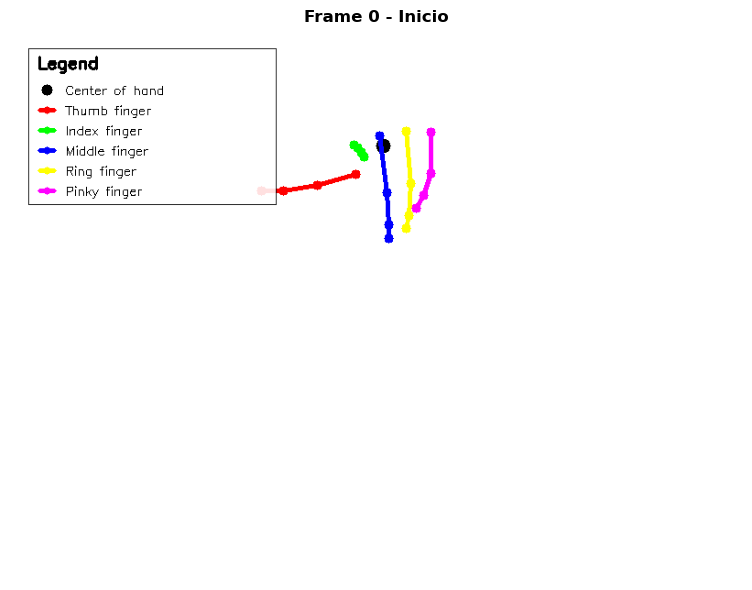

In [ ]:
class SkeletonVisualizer:
    """Visualiza esqueletos en 2D y 3D desde datos XML."""
    
    LEGEND_ITEMS = [
        ('Center of hand', (0, 0, 0)),
        ('Thumb', FINGER_COLORS['Thumb']),
        ('Index', FINGER_COLORS['Index']),
        ('Middle', FINGER_COLORS['Middle']),
        ('Ring', FINGER_COLORS['Ring']),
        ('Pinky', FINGER_COLORS['Pinky']),
    ]
    
    @staticmethod
    def draw_legend(canvas: np.ndarray, anchor: Tuple[int, int] = (100, 100)) -> np.ndarray:
        """Dibuja una leyenda simple sobre la imagen."""
        x0, y0 = anchor
        box_width = 270
        box_height = 170
        overlay = canvas.copy()
        cv2.rectangle(overlay, (x0, y0), (x0 + box_width, y0 + box_height), (255, 255, 255), -1)
        cv2.rectangle(overlay, (x0, y0), (x0 + box_width, y0 + box_height), (0, 0, 0), 1)
        cv2.addWeighted(overlay, 0.88, canvas, 0.12, 0, canvas)
        cv2.putText(canvas, 'Legend', (x0 + 10, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
        
        y = y0 + 45
        cv2.circle(canvas, (x0 + 20, y), 6, (0, 0, 0), -1)
        cv2.putText(canvas, 'Center of hand', (x0 + 40, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)
        for name, color in SkeletonVisualizer.LEGEND_ITEMS[1:]:
            y += 22
            cv2.line(canvas, (x0 + 12, y), (x0 + 28, y), color, 3)
            cv2.circle(canvas, (x0 + 20, y), 4, color, -1)
            cv2.putText(canvas, f'{name} finger', (x0 + 40, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)
        return canvas
    
    @staticmethod
    def draw_skeleton_2d(frame_data: Dict, canvas_size: Tuple[int, int] = CANVAS_SIZE, include_legend: bool = True) -> np.ndarray:
        """Dibuja el esqueleto en 2D usando proyección ortográfica."""
        canvas = np.ones((*canvas_size[::-1], 3), dtype=np.uint8) * 255
        
        if not frame_data.get('hand_center'):
            if include_legend:
                canvas = SkeletonVisualizer.draw_legend(canvas)
            return canvas
        
        def project_3d_to_2d(point_3d):
            """Proyecta puntos 3D a 2D."""
            if not point_3d or len(point_3d) < 3:
                return (int(canvas_size[0]/2), int(canvas_size[1]/2))
            
            x, y, z = float(point_3d[0]), float(point_3d[1]), float(point_3d[2])
            
            # Escalar y centrar
            scale = (canvas_size[0] - 200) / 400
            px = int(canvas_size[0]/2 + x * scale)
            py = int(canvas_size[1]/2 - y * scale)
            
            px = max(0, min(canvas_size[0]-1, px))
            py = max(0, min(canvas_size[1]-1, py))
            
            return (px, py)
        
        # Dibujar centro de mano
        center_2d = project_3d_to_2d(frame_data['hand_center'])
        cv2.circle(canvas, center_2d, 8, (0, 0, 0), -1)
        
        # Dibujar dedos
        for finger_name in SkeletalDataParser.FINGER_NAMES:
            finger_data = frame_data.get('fingers', {}).get(finger_name, {})
            
            if not finger_data:
                continue
            
            color = FINGER_COLORS.get(finger_name, (128, 128, 128))
            
            # Obtener articulaciones en orden
            joints = []
            for joint_name in ['mcpPosition', 'pipPosition', 'dipPosition', 'TipPosition']:
                if joint_name in finger_data:
                    joints.append(finger_data[joint_name])
            
            if joints:
                joints_2d = [project_3d_to_2d(j) for j in joints]
                
                # Dibujar líneas conectando articulaciones
                for i in range(len(joints_2d) - 1):
                    cv2.line(canvas, joints_2d[i], joints_2d[i+1], color, 3)
                
                # Dibujar círculos en articulaciones
                for pt in joints_2d:
                    cv2.circle(canvas, pt, 5, color, -1)
        
        if include_legend:
            canvas = SkeletonVisualizer.draw_legend(canvas)
        return canvas
    
    @staticmethod
    def plot_frame_2d(frame_data: Dict, title: str = "Hand Skeleton"):
        """Visualiza un frame en 2D con matplotlib."""
        canvas = SkeletonVisualizer.draw_skeleton_2d(frame_data, include_legend=True)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

# Probar visualizador
print("Probando visualizador...")
if frames:
    print(f"Visualizando frames {0}, {len(frames)//2}, {len(frames)-1}...")
    SkeletonVisualizer.plot_frame_2d(frames[0], f"Frame 0 - Inicio")

## Sección 7: Generador de videos en cámara lenta

In [12]:
class VideoReconstructor:
    """Reconstruye videos en cámara lenta desde datos esqueletales."""
    
    def __init__(self, fps_output: int = FPS_SLOWMOTION, canvas_size: Tuple[int, int] = CANVAS_SIZE):
        self.fps_output = fps_output
        self.canvas_size = canvas_size
        self.frame_duplication = FPS_ORIGINAL // fps_output
    
    def render_video_slowmotion(self, frames: List[Dict], output_path: str, 
                                gesture_label: str = "", patient_id: str = "") -> bool:
        """Genera un video en cámara lenta duplicando frames."""
        
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        
        try:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(str(output_path), fourcc, self.fps_output, self.canvas_size)
            
            if not writer.isOpened():
                print(f"❌ Error: No se puede crear el video {output_path}")
                return False
            
            print(f"🎬 Renderizando video ({len(frames)} frames → {len(frames) * self.frame_duplication} con slowmo)...")
            
            frame_count = 0
            for i, frame_data in enumerate(frames):
                # Dibujar esqueleto
                canvas = SkeletonVisualizer.draw_skeleton_2d(frame_data, self.canvas_size)
                
                # Agregar información
                text = f"{gesture_label} | Frame {i+1}/{len(frames)}"
                cv2.putText(canvas, text, (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
                
                cv2.putText(canvas, f"Patient {patient_id}", (10, self.canvas_size[1] - 20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
                
                # Duplicar frame para efecto slow motion
                for _ in range(self.frame_duplication):
                    writer.write(canvas)
                    frame_count += 1
                
                if (i + 1) % max(1, len(frames)//3) == 0:
                    print(f"  ✓ Procesado {i+1}/{len(frames)} frames")
            
            writer.release()
            print(f"✅ Video guardado: {output_path}")
            print(f"   Total frames escritos: {frame_count} a {self.fps_output} FPS")
            return True
            
        except Exception as e:
            print(f"❌ Error al renderizar video: {e}")
            return False

# Probar generador
print("\nProbando generador de video...")
if frames:
    test_output = OUTPUT_BASE / "test_video.mp4"
    reconstructor = VideoReconstructor()
    success = reconstructor.render_video_slowmotion(
        frames, 
        str(test_output),
        gesture_label="02_l",
        patient_id="00"
    )
    if success:
        print(f"✓ Video de prueba creado exitosamente")


Probando generador de video...
🎬 Renderizando video (6 frames → 18 con slowmo)...
  ✓ Procesado 2/6 frames
  ✓ Procesado 4/6 frames
  ✓ Procesado 6/6 frames
✅ Video guardado: ..\skeleton_videos\test_video.mp4
   Total frames escritos: 18 a 10 FPS
✓ Video de prueba creado exitosamente


## Sección 8: Procesamiento batch de gestos por paciente

In [13]:
def process_all_gestures():
    """Procesa todos los gestos, generando un video por gesto con la mejor secuencia global."""
    
    reconstructor = VideoReconstructor()
    results = []
    
    for gesture_name in sorted(best_sequences_by_gesture.keys()):
        seq_info = best_sequences_by_gesture[gesture_name]
        seq_path = Path(seq_info['path'])
        patient_id = seq_info['patient_id']
        
        print(f"\n{'='*70}")
        print(f"PROCESANDO GESTO {gesture_name}")
        print(f"{'='*70}")
        print(f"  Paciente: {patient_id} | Tipo: {seq_info['seq_type']} | Frames: {seq_info['n_frames']} | ID: {seq_info['seq_id']} | score={seq_info['quality_score']:.3f}")
        
        # Cargar frames
        frames = SkeletalDataParser.load_gesture_sequence(str(seq_path))
        
        if not frames:
            print(f"     ❌ Error: No se pudieron cargar frames")
            results.append({
                'patient_id': patient_id,
                'gesture_name': gesture_name,
                'seq_type': seq_info['seq_type'],
                'seq_id': seq_info['seq_id'],
                'status': 'failed_load',
                'n_frames': seq_info['n_frames'],
                'quality_score': seq_info['quality_score'],
                'output_path': None
            })
            continue
        
        # Generar ruta de salida
        output_path = OUTPUT_BASE / f"gesture_{gesture_name}" / f"{gesture_name}_{seq_info['seq_type']}.mp4"
        
        # Renderizar video
        success = reconstructor.render_video_slowmotion(
            frames,
            str(output_path),
            gesture_label=gesture_name,
            patient_id=patient_id
        )
        
        if success:
            print(f"     ✅ Video generado: {output_path.name}")
            status = 'success'
        else:
            status = 'failed_render'
        
        results.append({
            'patient_id': patient_id,
            'gesture_name': gesture_name,
            'seq_type': seq_info['seq_type'],
            'seq_id': seq_info['seq_id'],
            'status': status,
            'n_frames': seq_info['n_frames'],
            'quality_score': seq_info['quality_score'],
            'output_path': str(output_path) if success else None
        })
    
    return pd.DataFrame(results)

# Ejecutar procesamiento
print("\n" + "="*70)
print("INICIANDO PROCESAMIENTO DE TODOS LOS GESTOS")
print("="*70)

results_df = process_all_gestures()

print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)
print(f"\nTotal procesados: {len(results_df)}")
print(f"Exitosos: {len(results_df[results_df['status'] == 'success'])}")
print(f"Fallidos: {len(results_df[results_df['status'] != 'success'])}")

print("\nPor gesto:")
for gesture_name in sorted(results_df['gesture_name'].unique()):
    gesture_results = results_df[results_df['gesture_name'] == gesture_name]
    success_count = len(gesture_results[gesture_results['status'] == 'success'])
    total_count = len(gesture_results)
    print(f"  Gesto {gesture_name}: {success_count}/{total_count} videos generados")


INICIANDO PROCESAMIENTO DE TODOS LOS GESTOS

PROCESANDO GESTO 02_l
  Paciente: 06 | Tipo: test_gesture | Frames: 6 | ID: 00 | score=5.650
🎬 Renderizando video (6 frames → 18 con slowmo)...
  ✓ Procesado 2/6 frames
  ✓ Procesado 4/6 frames
  ✓ Procesado 6/6 frames
✅ Video guardado: ..\skeleton_videos\gesture_02_l\02_l_test_gesture.mp4
   Total frames escritos: 18 a 10 FPS
     ✅ Video generado: 02_l_test_gesture.mp4

PROCESANDO GESTO 04_fist_moved
  Paciente: 06 | Tipo: test_gesture | Frames: 6 | ID: 00 | score=4.719
🎬 Renderizando video (6 frames → 18 con slowmo)...
  ✓ Procesado 2/6 frames
  ✓ Procesado 4/6 frames
  ✓ Procesado 6/6 frames
✅ Video guardado: ..\skeleton_videos\gesture_04_fist_moved\04_fist_moved_test_gesture.mp4
   Total frames escritos: 18 a 10 FPS
     ✅ Video generado: 04_fist_moved_test_gesture.mp4

PROCESANDO GESTO 06_index
  Paciente: 11 | Tipo: test_gesture | Frames: 6 | ID: 00 | score=5.555
🎬 Renderizando video (6 frames → 18 con slowmo)...
  ✓ Procesado 2/6 fr

## Sección 9: Análisis de resultados y exportación

In [14]:
# Mostrar tabla de resultados detallada
print("\nTABLA DETALLADA DE RESULTADOS:")
print(results_df.to_string(index=False))

# Exportar resultados a CSV
csv_output = OUTPUT_BASE / "processing_results.csv"
results_df.to_csv(csv_output, index=False)
print(f"\n✓ Resultados exportados a: {csv_output}")

# Crear resumen por gesto
print("\n" + "="*70)
print("RESUMEN POR GESTO (MEJOR SECUENCIA GLOBAL)")
print("="*70)

gesture_summary = results_df.groupby('gesture_name').agg({
    'status': lambda x: (x == 'success').sum(),
    'n_frames': 'first',
    'quality_score': 'first'
}).rename(columns={'status': 'n_successful'})

gesture_summary['total'] = results_df.groupby('gesture_name').size()
print(gesture_summary[['n_successful', 'total', 'n_frames', 'quality_score']].to_string())

# Información de videos generados
success_videos = results_df[results_df['status'] == 'success'].copy()
if len(success_videos) > 0:
    print(f"\n{'='*70}")
    print(f"VIDEOS GENERADOS ({len(success_videos)} total)")
    print(f"{'='*70}")
    
    for _, row in success_videos.iterrows():
        output_path = Path(row['output_path'])
        if output_path.exists():
            file_size = output_path.stat().st_size / (1024*1024)  # MB
            print(f"\n✓ {row['gesture_name']:20s} | Paciente {row['patient_id']} | {file_size:.1f} MB")
            print(f"  📁 {output_path}")
        else:
            print(f"\n⚠ {row['gesture_name']:20s} | Archivo no encontrado")

# Resumen final
print(f"\n{'='*70}")
print("RESUMEN FINAL DE PROCESAMIENTO")
print(f"{'='*70}")
print(f"Pacientes representados: {len(results_df['patient_id'].unique())}")
print(f"Gestos únicos procesados: {len(results_df['gesture_name'].unique())}")
print(f"Videos generados exitosamente: {len(results_df[results_df['status'] == 'success'])}")
print(f"Videos fallidos: {len(results_df[results_df['status'] != 'success'])}")
print(f"\nDirectorio de salida: {OUTPUT_BASE}")
print(f"Archivos guardados en carpetas por gesto")
print(f"Cada gesto tiene un video a cámara lenta ({FPS_SLOWMOTION} FPS)")
print(f"\n✅ Procesamiento completado")


TABLA DETALLADA DE RESULTADOS:
patient_id  gesture_name     seq_type seq_id  status  n_frames  quality_score                                                             output_path
        06          02_l test_gesture     00 success         6       5.649620                   ..\skeleton_videos\gesture_02_l\02_l_test_gesture.mp4
        06 04_fist_moved test_gesture     00 success         6       4.719243 ..\skeleton_videos\gesture_04_fist_moved\04_fist_moved_test_gesture.mp4
        11      06_index test_gesture     00 success         6       5.555070           ..\skeleton_videos\gesture_06_index\06_index_test_gesture.mp4
        07         07_ok test_gesture     01 success         6       5.670000                 ..\skeleton_videos\gesture_07_ok\07_ok_test_gesture.mp4
        01          09_c test_gesture     00 success         6       5.460051                   ..\skeleton_videos\gesture_09_c\09_c_test_gesture.mp4
        13      11_heavy test_gesture     01 success         6      

## Sección 10 (Opcional): Visualización de frames de muestra

Visualizando frames de muestra de gestos procesados...



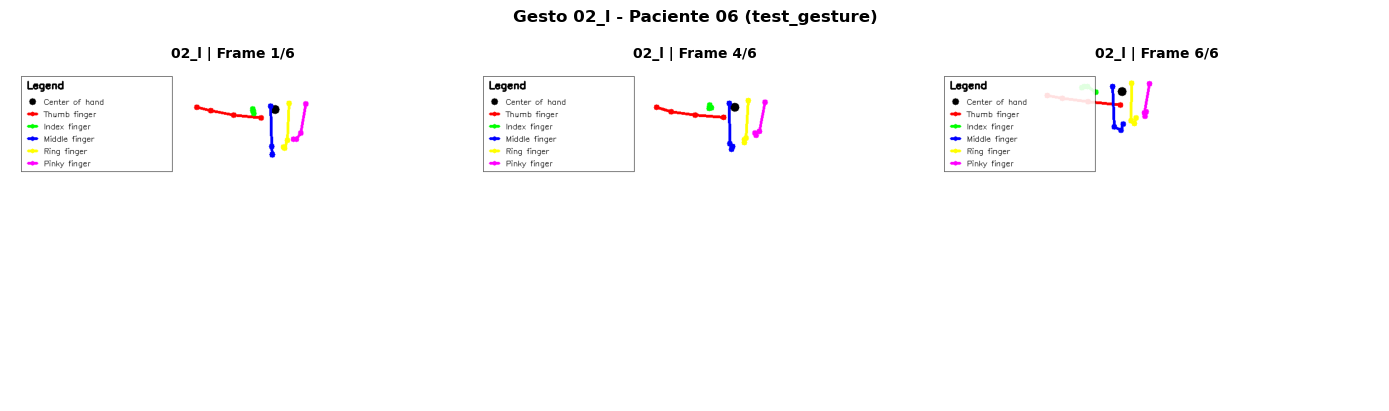

✓ 02_l (Paciente 06): 6 frames



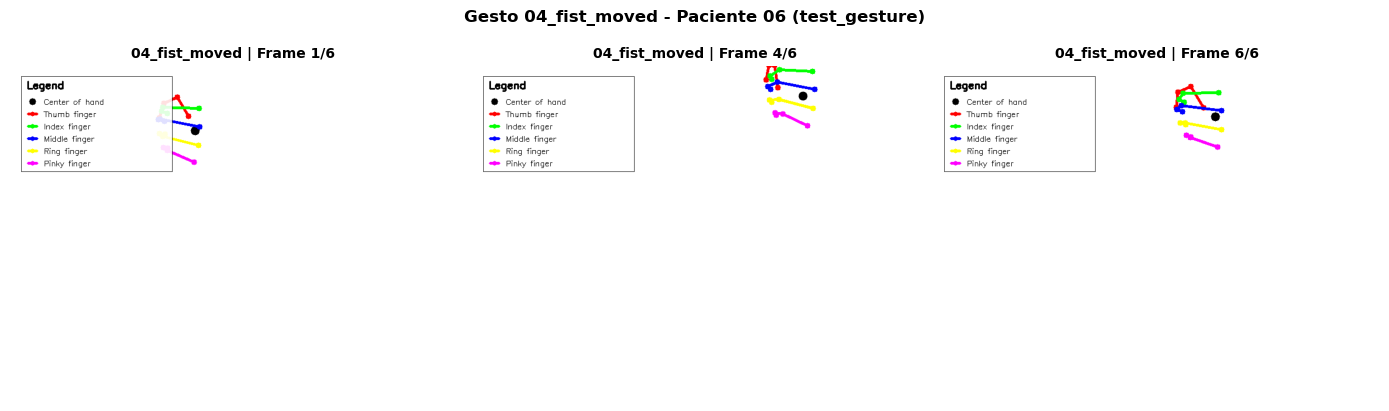

✓ 04_fist_moved (Paciente 06): 6 frames



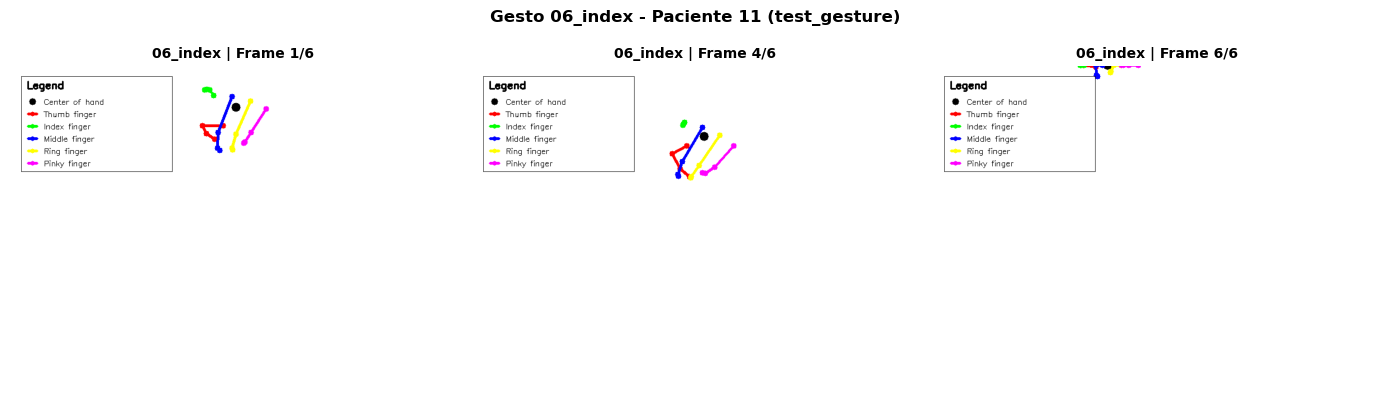

✓ 06_index (Paciente 11): 6 frames



In [15]:
# Visualizar frames de los primeros gestos procesados exitosamente
success_results = results_df[results_df['status'] == 'success'].head(3)

if len(success_results) > 0:
    print("Visualizando frames de muestra de gestos procesados...\n")
    
    for _, result in success_results.iterrows():
        seq_path = best_sequences_by_gesture[result['gesture_name']]['path']
        frames = SkeletalDataParser.load_gesture_sequence(seq_path)
        
        if frames:
            # Visualizar inicio, medio y fin
            indices = [0, len(frames)//2, len(frames)-1]
            indices = [i for i in indices if i < len(frames)]
            
            fig, axes = plt.subplots(1, len(indices), figsize=(14, 4))
            if len(indices) == 1:
                axes = [axes]
            
            for idx, frame_idx in enumerate(indices):
                canvas = SkeletonVisualizer.draw_skeleton_2d(frames[frame_idx], include_legend=True)
                axes[idx].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
                axes[idx].set_title(f"{result['gesture_name']} | Frame {frame_idx+1}/{len(frames)}", 
                                   fontsize=10, fontweight='bold')
                axes[idx].axis('off')
            
            plt.suptitle(f"Gesto {result['gesture_name']} - Paciente {result['patient_id']} ({result['seq_type']})", 
                        fontsize=12, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()
            print(f"✓ {result['gesture_name']} (Paciente {result['patient_id']}): {len(frames)} frames\n")

## Sección 11: Reconstrucción de Poses Estáticas (Sin Video)

In [20]:
# Celda de diagnóstico para explorar test_pose
print("=" * 70)
print("DIAGNÓSTICO: Explorando estructura de test_pose")
print("=" * 70)

print(f"\nDataset base: {DATASET_BASE}")
print(f"Existe: {DATASET_BASE.exists()}")

if DATASET_BASE.exists():
    patient_dirs = sorted([d for d in DATASET_BASE.iterdir() if d.is_dir() and d.name.isdigit()])
    print(f"\nTotal de pacientes: {len(patient_dirs)}")
    
    for patient_dir in patient_dirs[:2]:  # Mostrar solo primeros 2
        patient_id = patient_dir.name
        test_pose_path = patient_dir / 'test_pose'
        
        print(f"\n  Paciente {patient_id}:")
        print(f"    test_pose existe: {test_pose_path.exists()}")
        
        if test_pose_path.exists():
            pose_dirs = sorted([d for d in test_pose_path.iterdir() if d.is_dir()])
            print(f"    Poses en test_pose: {len(pose_dirs)}")
            
            if pose_dirs:
                for pose_dir in pose_dirs[:2]:  # Mostrar primeras 2 poses
                    pose_name = pose_dir.name
                    print(f"      • {pose_name}:")
                    
                    # Listar contenido directo
                    items = list(pose_dir.iterdir())
                    print(f"        Contenido: {len(items)} items")
                    
                    for item in items[:3]:
                        if item.is_dir():
                            xml_count = len(list(item.glob("*.xml")))
                            print(f"          - {item.name}/ ({xml_count} XML files)")
                        else:
                            print(f"          - {item.name} (file)")


DIAGNÓSTICO: Explorando estructura de test_pose

Dataset base: ..\data\dataset_skeletal_hand_gesture\skeletal
Existe: True

Total de pacientes: 15

  Paciente 00:
    test_pose existe: True
    Poses en test_pose: 16
      • 01_palm:
        Contenido: 42 items
          - frame_21811.xml (file)
          - frame_21825.xml (file)
          - frame_21837.xml (file)
      • 02_l:
        Contenido: 38 items
          - frame_4312.xml (file)
          - frame_4324.xml (file)
          - frame_4448.xml (file)

  Paciente 01:
    test_pose existe: True
    Poses en test_pose: 16
      • 01_palm:
        Contenido: 29 items
          - frame_101634.xml (file)
          - frame_101648.xml (file)
          - frame_101662.xml (file)
      • 02_l:
        Contenido: 40 items
          - frame_243400.xml (file)
          - frame_243831.xml (file)
          - frame_243887.xml (file)


In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

def find_static_poses():
    """Encuentra todas las poses estáticas en test_pose (XMLs sueltos, no secuencias)."""
    static_poses = {}
    
    print("  Buscando poses estáticas...")
    
    patient_dirs = sorted([d for d in DATASET_BASE.iterdir() if d.is_dir() and d.name.isdigit()])
    print(f"  Explorando {len(patient_dirs)} pacientes...")
    
    for patient_dir in patient_dirs:
        patient_id = patient_dir.name
        test_pose_path = patient_dir / 'test_pose'
        
        if not test_pose_path.exists():
            continue
        
        # Listar todas las poses en test_pose
        pose_dirs = sorted([d for d in test_pose_path.iterdir() if d.is_dir()])
        
        for pose_dir in pose_dirs:
            pose_name = pose_dir.name
            
            # En test_pose, los XMLs están directamente, no en subcarpetas
            xml_files = sorted(pose_dir.glob("frame_*.xml"))
            
            if len(xml_files) > 0:
                # Usar el primer frame como representación de la pose
                first_xml = xml_files[0]
                frame_data = SkeletalDataParser.parse_xml_frame(str(first_xml))
                
                if frame_data:
                    if pose_name not in static_poses:
                        static_poses[pose_name] = []
                    
                    static_poses[pose_name].append({
                        'patient_id': patient_id,
                        'frame_data': frame_data,
                        'xml_path': str(first_xml),
                        'n_frames': len(xml_files)
                    })
    
    return static_poses


def create_static_pose_grids():
    """Crea grillas de imágenes para poses estáticas, mostrando variación entre pacientes."""
    
    print("=" * 70)
    print("RECONSTRUYENDO POSES ESTÁTICAS")
    print("=" * 70)
    
    # Encontrar poses estáticas
    static_poses = find_static_poses()
    
    if not static_poses:
        print("⚠ No se encontraron poses estáticas")
        return pd.DataFrame()
    
    print(f"\n✓ Poses estáticas encontradas: {len(static_poses)}")
    for pose_name, instances in sorted(static_poses.items()):
        print(f"  • {pose_name:20s} - {len(instances)} instancias de pacientes")
    
    # Crear carpeta de salida
    static_poses_dir = OUTPUT_BASE / "static_poses"
    static_poses_dir.mkdir(parents=True, exist_ok=True)
    
    results = []
    
    # Procesar cada pose estática
    for pose_name in sorted(static_poses.keys()):
        instances = static_poses[pose_name]
        
        print(f"\n{'='*70}")
        print(f"PROCESANDO POSE: {pose_name}")
        print(f"{'='*70}")
        print(f"  Total de instancias: {len(instances)}")
        
        # Crear grilla de imágenes
        # Determinar tamaño de grilla (preferir aprox. cuadrado)
        n_instances = len(instances)
        n_cols = int(np.ceil(np.sqrt(n_instances)))
        n_rows = int(np.ceil(n_instances / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
        
        # Garantizar que axes sea 2D
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1 or n_cols == 1:
            axes = axes.reshape(n_rows, n_cols)
        
        # Llenar grilla
        for idx, instance in enumerate(instances):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]
            
            patient_id = instance['patient_id']
            frame_data = instance['frame_data']
            n_frames = instance['n_frames']
            
            # Generar imagen del esqueleto (sin leyenda para mejor visualización en grilla)
            canvas = SkeletonVisualizer.draw_skeleton_2d(frame_data, CANVAS_SIZE, include_legend=False)
            
            # Mostrar en subplot
            ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Paciente {patient_id}\n({n_frames} frames)", fontsize=10, fontweight='bold')
            ax.axis('off')
        
        # Ocultar subplots no utilizados
        for idx in range(n_instances, n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            axes[row, col].axis('off')
        
        # Configurar figura
        fig.suptitle(f"Pose Estática: {pose_name}", fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        # Guardar imagen
        output_path = static_poses_dir / f"pose_{pose_name}_grid.png"
        plt.savefig(str(output_path), dpi=100, bbox_inches='tight')
        plt.close()
        
        print(f"  ✅ Grilla creada: {output_path.name}")
        
        results.append({
            'pose_name': pose_name,
            'n_instances': len(instances),
            'grid_cols': n_cols,
            'grid_rows': n_rows,
            'status': 'success',
            'output_path': str(output_path)
        })
    
    return pd.DataFrame(results)


# Ejecutar procesamiento de poses estáticas
static_poses_df = create_static_pose_grids()

print("\n" + "="*70)
print("RESUMEN DE POSES ESTÁTICAS PROCESADAS")
print("="*70)

if len(static_poses_df) > 0:
    print("\n" + static_poses_df.to_string(index=False))
    
    # Crear galería visual de muestras
    print(f"\n{'='*70}")
    print("GALERÍA DE POSES ESTÁTICAS (MUESTRAS)")
    print(f"{'='*70}")
    
    sample_poses = static_poses_df.head(5)
    
    for _, pose_row in sample_poses.iterrows():
        pose_path = Path(pose_row['output_path'])
        if pose_path.exists():
            print(f"\n✓ {pose_row['pose_name']}")
            print(f"  Instancias: {pose_row['n_instances']} pacientes")
            print(f"  Grilla: {pose_row['grid_rows']}x{pose_row['grid_cols']}")
            print(f"  Archivo: {pose_path.name}")
    
    print(f"\n{'='*70}")
    print(f"✅ Total: {len(static_poses_df)} poses estáticas procesadas")
    print(f"   Guardadas en: {OUTPUT_BASE / 'static_poses'}")
    print(f"{'='*70}")
else:
    print("⚠ No hay poses estáticas para procesar")

RECONSTRUYENDO POSES ESTÁTICAS
  Buscando poses estáticas...
  Explorando 15 pacientes...

✓ Poses estáticas encontradas: 16
  • 01_palm              - 15 instancias de pacientes
  • 02_l                 - 14 instancias de pacientes
  • 04_fist_moved        - 14 instancias de pacientes
  • 05_down              - 15 instancias de pacientes
  • 06_index             - 15 instancias de pacientes
  • 07_ok                - 15 instancias de pacientes
  • 08_palm_m            - 15 instancias de pacientes
  • 09_c                 - 14 instancias de pacientes
  • 11_heavy             - 15 instancias de pacientes
  • 12_hang              - 15 instancias de pacientes
  • 13_two               - 15 instancias de pacientes
  • 14_three             - 15 instancias de pacientes
  • 15_four              - 15 instancias de pacientes
  • 16_five              - 15 instancias de pacientes
  • 17_palm_u            - 15 instancias de pacientes
  • 18_up                - 15 instancias de pacientes

PROCESANDO

In [ ]:
# Verificar archivos creados
print("=" * 70)
print("VERIFICACIÓN DE ARCHIVOS GENERADOS")
print("=" * 70)

static_poses_dir = OUTPUT_BASE / "static_poses"

if static_poses_dir.exists():
    png_files = list(static_poses_dir.glob("pose_*.png"))
    print(f"\n✅ Carpeta creada: {static_poses_dir}")
    print(f"✅ Archivos generados: {len(png_files)} imágenes PNG")
    
    if png_files:
        print(f"\nPrimeros 10 archivos:")
        for i, png_file in enumerate(sorted(png_files)[:10]):
            size_mb = png_file.stat().st_size / (1024*1024)
            print(f"  {i+1}. {png_file.name:40s} ({size_mb:.2f} MB)")
        
        if len(png_files) > 10:
            print(f"  ... y {len(png_files)-10} archivos más")
        
        print(f"\nTamaño total: {sum(f.stat().st_size for f in png_files) / (1024*1024):.1f} MB")
else:
    print(f"⚠ La carpeta no se creó: {static_poses_dir}")

VERIFICACIÓN DE ARCHIVOS GENERADOS

✅ Carpeta creada: ..\skeleton_videos\static_poses
✅ Archivos generados: 16 imágenes PNG

Primeros 10 archivos:
  1. pose_01_palm_grid.png                    (0.06 MB)
  2. pose_02_l_grid.png                       (0.06 MB)
  3. pose_04_fist_moved_grid.png              (0.06 MB)
  4. pose_05_down_grid.png                    (0.06 MB)
  5. pose_06_index_grid.png                   (0.06 MB)
  6. pose_07_ok_grid.png                      (0.06 MB)
  7. pose_08_palm_m_grid.png                  (0.05 MB)
  8. pose_09_c_grid.png                       (0.05 MB)
  9. pose_11_heavy_grid.png                   (0.06 MB)
  10. pose_12_hang_grid.png                    (0.06 MB)
  ... y 6 archivos más

Tamaño total: 0.9 MB


: 